In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

%matplotlib inline

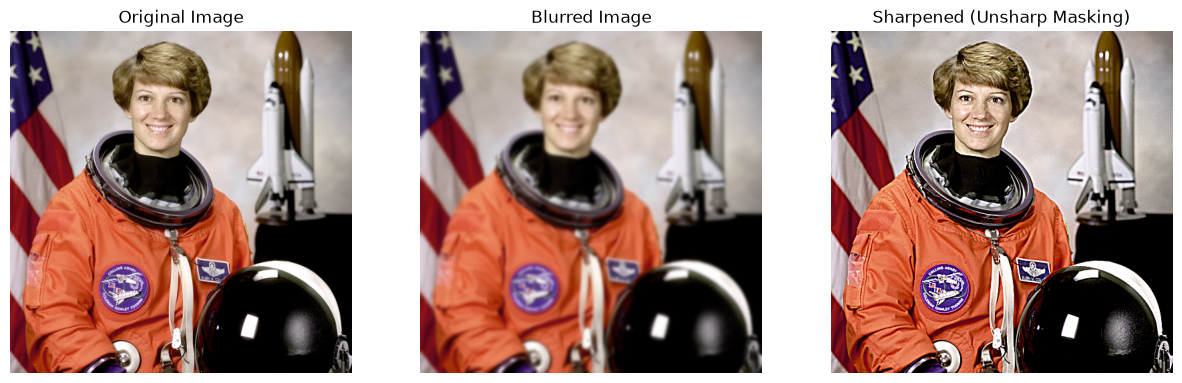

In [2]:
image = data.astronaut()

# Gaussian sigma (blur strength)
sigma = 2

# Sharpening strength
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);      ax[0].set_title("Original Image");              ax[0].axis("off")
ax[1].imshow(blurred);    ax[1].set_title("Blurred Image");               ax[1].axis("off")
ax[2].imshow(sharpened);  ax[2].set_title("Sharpened (Unsharp Masking)"); ax[2].axis("off")
plt.show()

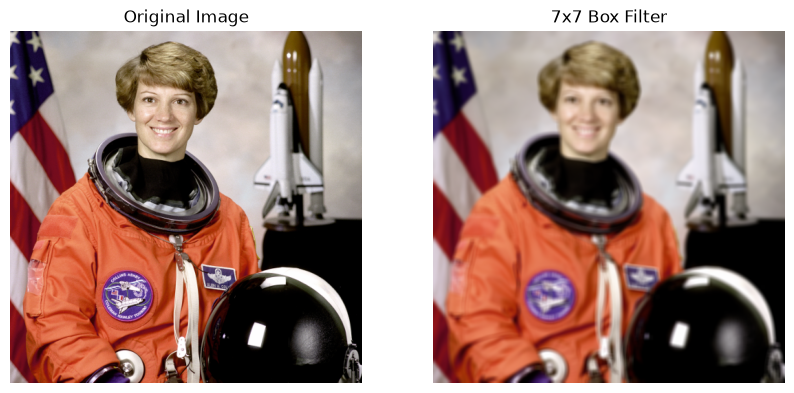

In [3]:
image = data.astronaut()
image_float = image.astype(np.float32) / 255.0

# Build the 7x7 box kernel manually
box_kernel_7 = np.ones((7, 7), np.float32) / 49

# Apply convolution
box_filtered_7 = cv2.filter2D(image_float, -1, box_kernel_7)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image);            ax[0].set_title("Original Image");       ax[0].axis("off")
ax[1].imshow(box_filtered_7);   ax[1].set_title("7x7 Box Filter");       ax[1].axis("off")
plt.show()

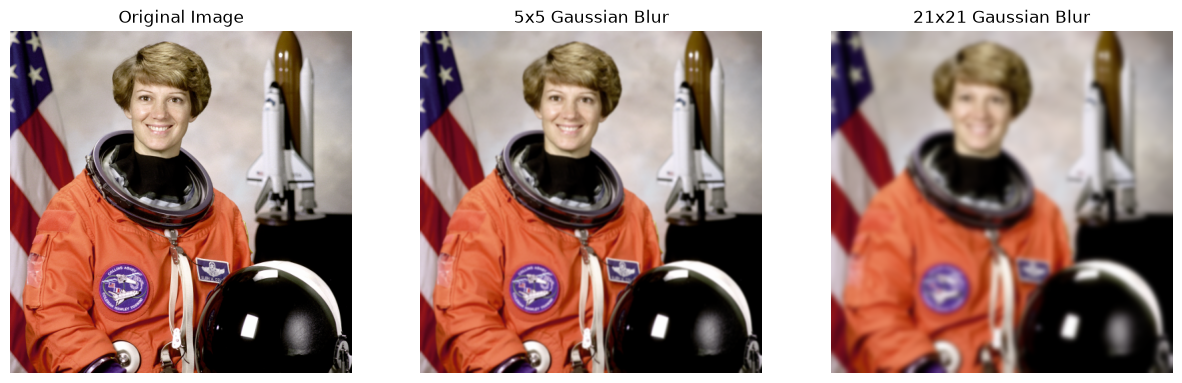

In [4]:
gaussian_5 = cv2.GaussianBlur(image_float, (5, 5), 0)
gaussian_21 = cv2.GaussianBlur(image_float, (21, 21), 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);          ax[0].set_title("Original Image");          ax[0].axis("off")
ax[1].imshow(gaussian_5);     ax[1].set_title("5x5 Gaussian Blur");       ax[1].axis("off")
ax[2].imshow(gaussian_21);    ax[2].set_title("21x21 Gaussian Blur");     ax[2].axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-6.2431374..4.54902].


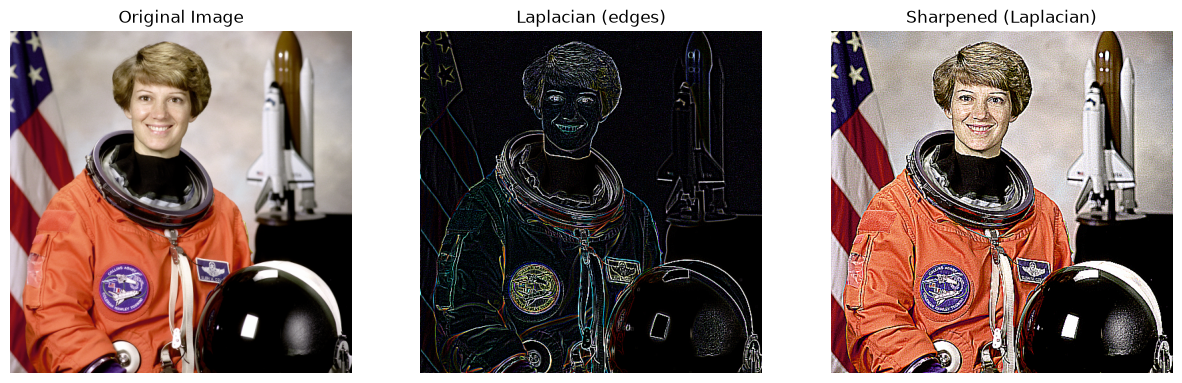

In [5]:
# 1. Read the image
image = data.astronaut()
# 2. Convert to float32
image_float = image.astype(np.float32) / 255.0
# 3. Apply cv2.Laplacian()
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)
# 4. Sharpen
sharpened_laplacian = np.clip(image_float - laplacian, 0, 1)

# 5. Plot the three images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);                  ax[0].set_title("Original Image");           ax[0].axis("off")
ax[1].imshow(laplacian, cmap="gray"); ax[1].set_title("Laplacian (edges)");        ax[1].axis("off")
ax[2].imshow(sharpened_laplacian);    ax[2].set_title("Sharpened (Laplacian)");    ax[2].axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0685897e-14..0.9969015].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9.214851e-15..0.99620044].


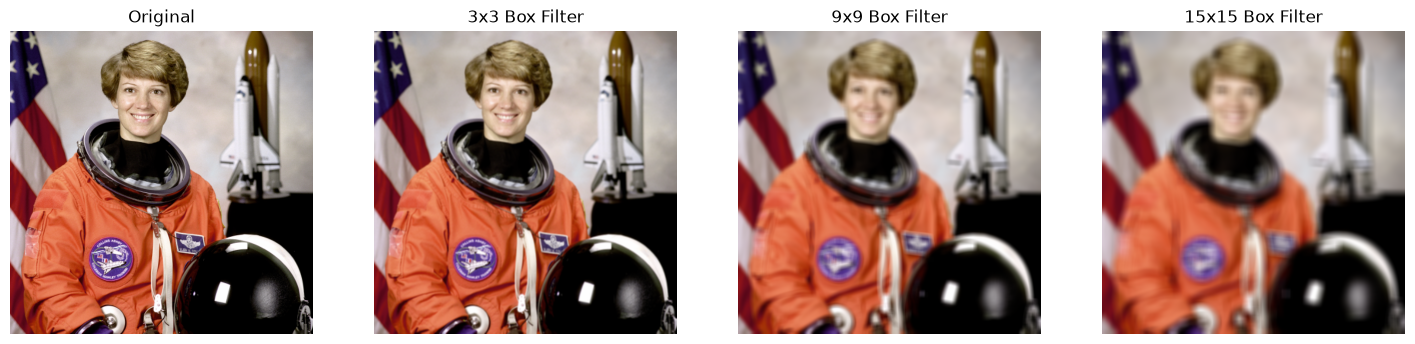

In [6]:
image = data.astronaut()
image_float = image.astype(np.float32) / 255.0

box_3   = cv2.filter2D(image_float, -1, np.ones((3, 3), np.float32) / 9)
box_9   = cv2.filter2D(image_float, -1, np.ones((9, 9), np.float32) / 81)
box_15  = cv2.filter2D(image_float, -1, np.ones((15, 15), np.float32) / 225)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(image);   ax[0].set_title("Original");        ax[0].axis("off")
ax[1].imshow(box_3);   ax[1].set_title("3x3 Box Filter");  ax[1].axis("off")
ax[2].imshow(box_9);   ax[2].set_title("9x9 Box Filter");  ax[2].axis("off")
ax[3].imshow(box_15);  ax[3].set_title("15x15 Box Filter"); ax[3].axis("off")
plt.show()

In [ ]:
image = data.astronaut()

# Add salt-and-pepper noise
noisy_image = image.copy()
prob = 0.02
rnd = np.random.rand(*image.shape[:2])
noisy_image[rnd < prob / 2] = 0
noisy_image[rnd > 1 - prob / 2] = 255

# Apply median filter and Gaussian blur for comparison
median_filtered = cv2.medianBlur(noisy_image, 5)
gaussian_filtered = cv2.GaussianBlur(noisy_image, (5, 5), 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(noisy_image);        ax[0].set_title("Noisy Image (Salt & Pepper)"); ax[0].axis("off")
ax[1].imshow(gaussian_filtered);  ax[1].set_title("Gaussian Blur");               ax[1].axis("off")
ax[2].imshow(median_filtered);    ax[2].set_title("Median Filter");               ax[2].axis("off")
plt.show()

In [ ]:
image = data.astronaut()

gaussian_blur = cv2.GaussianBlur(image, (9, 9), 0)
bilateral_filtered = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);                ax[0].set_title("Original Image");    ax[0].axis("off")
ax[1].imshow(gaussian_blur);        ax[1].set_title("Gaussian Blur");     ax[1].axis("off")
ax[2].imshow(bilateral_filtered);   ax[2].set_title("Bilateral Filter");  ax[2].axis("off")
plt.show()